In [1]:
from argparse import Namespace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset, build_loader
from src.misc import load_config

In [2]:
CONFIG_PATH = ROOT / "config" / "model.yaml"
BATCH_SIZE = 6
PLANE_NAMES = ("xy", "xz", "yz")

In [3]:
args = Namespace(**load_config(CONFIG_PATH))
manifest = Path(args.axis_manifest)
if not manifest.is_absolute():
    manifest = CONFIG_PATH.parent / manifest
args.axis_manifest = manifest.resolve()
args.batch_size = BATCH_SIZE
args.augment = False

dataset = build_dataset(args)
loader = build_loader(dataset, args, device=torch.device("cpu"))
images, fractions, axis_conditions = next(iter(loader))

mean_fractions = [round(value, 4) for value in fractions.mean(dim=0).tolist()]
print(
    f"samples={len(dataset)} batch={tuple(images.shape)} "
    f"axis_counts={torch.bincount(axis_conditions, minlength=3).tolist()} "
    f"fractions={mean_fractions}"
)

samples=6720 batch=(6, 1, 64, 64) axis_counts=[2, 2, 2] fractions=[0.5576, 0.1548, 0.2876]


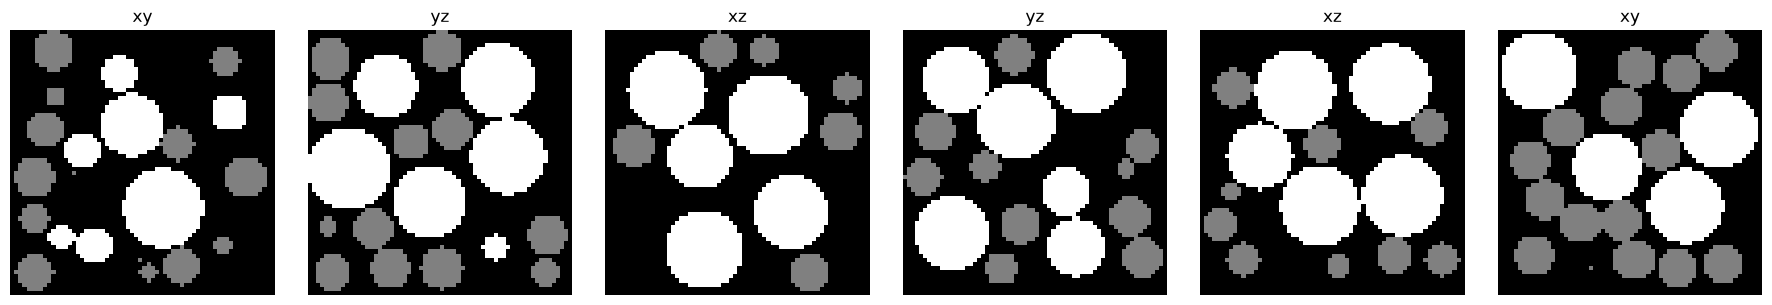

In [4]:
count = min(BATCH_SIZE, images.shape[0])
fig, axes = plt.subplots(1, count, figsize=(3 * count, 3), squeeze=False)
for axis, image, condition in zip(
    axes.ravel(), images[:count, 0], axis_conditions[:count]
):
    axis.imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=args.num_phases - 1,
        interpolation="nearest",
    )
    axis.set_title(PLANE_NAMES[int(condition)])
    axis.axis("off")
plt.tight_layout()